In [1]:
import os
import sys
#sys.path.append(os.path.abspath(os.path.join('../diffusionsim')))
from tqdm import tqdm
from pathlib import Path
import json
import numpy as np
import diffusionsim.training_utils as tru
from diffusionsim.trainers import *
import torch
import torch.nn as nn
from typing import Optional
from dataclasses import dataclass, asdict, field
from typing_extensions import Annotated
from pprint import pprint
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import scipy.stats as stats

In [2]:

from ipywidgets import interact, widgets
from matplotlib import pyplot as plt

os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/srv/conda/envs/notebook'
torch.set_grad_enabled(False); print("grad enabled: ", torch.is_grad_enabled())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

grad enabled:  False


'cuda'

In [3]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
#exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"

### Utils

In [4]:
def plot_loss(diff_logs, loss_type):
    total_timesteps = 210238
    for key, log in diff_logs.items():
        dconfig, tconfig = log['data_config'], log['training_config']
        bs, bli = dconfig['dataloader_params']['batch_size'] / 384, tconfig['batch_logging_interval']
        plt.plot(log['losses']['train'][loss_type], label=f"{run_id_mapping[key]}")
        batches_per_epoch = max(1, total_timesteps * dconfig['train_test_split'][0]  // ( bs * bli))
        num_batches, num_epochs = len(log['losses']['train'][loss_type]), tconfig['num_epochs'] + 1
        plt.xticks(np.arange(0, num_batches, batches_per_epoch), labels=np.arange(1, num_epochs))
    plt.title("Training Loss over time")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")  
    plt.legend()
    plt.show()

In [5]:
def plot_gradients(diff_logs, loss_type, param_name='0.weight'):
    total_timesteps = 210238
    for key, log in diff_logs.items():
        grads = log['gradients'][loss_type]
        dconfig, tconfig = log['data_config'], log['training_config']
        if (param_name not in grads.keys()):
            print(f"param_name {param_name} not found in {grads.keys()}, select another parameter")
            return
        grads = np.array(grads[param_name])
        print(grads.shape)
        bs, bli = dconfig['dataloader_params']['batch_size'] / 384, tconfig['batch_logging_interval']
        logs_per_epoch = max(1, total_timesteps * dconfig['train_test_split'][0]  // ( bs * bli))
        num_batches, num_epochs = grads.shape[0], tconfig['num_epochs'] + 1
        print(bs, bli, logs_per_epoch, num_batches, num_epochs)
        means, stds = grads[:,0], grads[:,1]
        plt.plot(means, label=key)
        plt.fill_between(range(len(means)), means - stds, means + stds, alpha=0.2)
        #plt.xticks(np.arange(0, num_batches, logs_per_epoch), labels=np.arange(1, num_epochs))
    plt.title(f"{loss_type} Gradient throughout training")
    plt.xlabel("Epochs")
    plt.ylabel("Gradient Magnitude")  
    plt.legend()
    plt.show()


In [6]:

def hist(data, title, **kwargs):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    plt.hist(data, **kwargs)
    if('label' in kwargs):
        plt.legend()
    plt.title(title)

In [7]:
def parse_log(fname):
    with open(fname) as f:
        lines = f.readlines()
    messages = []
    for line in lines:
        try:
            messages.append(json.loads(line.strip()))
        except json.JSONDecodeError:
            pass
    return messages

def plot_wait_time(messages, ax, title="Time waiting"):
    if title:
        ax.set_title(title)

    wait_times = []
    end = None
    for m in messages:
        if m["event"] == "training end":
            end = m["time"]
        if m["event"] == "training start" and end is not None:
            wait_times.append(m["time"] - end)

    wait_times = np.array(wait_times)
    max_show = wait_times.mean() + 3 * wait_times.std()

    print("average wait time", wait_times.mean())

    ax.hist(wait_times, bins=np.linspace(0, max_show, 100), color="#6D0EDB")[-1]
    ax.set_xlabel("time (sec)")

In [8]:
def plot_log(messages, ax, title=""):
    origin = messages[0]["time"]
    # Define the rows for each event type you want to visualize
    rows = {"setup": 4, "get-item": 3, "run-batch": 2, "train": 1, "epoch": 0}
    ax.set_yticks(list(rows.values()), labels=list(rows))
    if title:
        ax.set_title(title)
    data = {"batches": [], "getitem": []}
    for m in messages:
        t = m["time"] - origin
        if m["event"] == "setup end":
            ax.barh(
                rows["setup"], m["duration"], left=t - m["duration"], edgecolor="k", linewidth=0.1, color="#6D0EDB", zorder=1,
            )
        elif m["event"] == "get-item end":
            ax.barh(
                rows["get-item"], m["duration"], left=t - m["duration"], color="#F9C846", zorder=1,
            )
            data["getitem"].append(m["duration"])
        elif m["event"] == "run-batch end":
            ax.barh(
                rows["run-batch"], m["duration"], left=t - m["duration"], color="#C396F9", zorder=1,
            )
            data["batches"].append(m["duration"])
        elif m["event"] == "training end":
            ax.barh(
                rows["train"], m["duration"], left=t - m["duration"], color="#FF6554", zorder=1,
            )
        elif m["event"] == "epoch end":
            ax.barh(
                rows["epoch"], m["duration"], left=t - m["duration"], edgecolor="k", linewidth=0.1, color="#FF9E0D", zorder=1,
            )

    ax.grid(axis="x", zorder=0, alpha=0.5)
    ax.set_xlabel("time (sec)")

    print("average batch duration", np.mean(data["batches"]))
    print("average get-item duration", np.mean(data["getitem"]))

In [9]:
def plot(fname):
    messages = parse_log(fname)
    fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16, 6), width_ratios=[3, 1], dpi=400)

    plot_log(messages, axes[0], title="")
    plot_wait_time(messages, axes[1], title="")

    for m in messages:
        if m["event"] == "run start":
            text_str = "\n".join([f"{k}: {v}" for k, v in m["locals"].items() if v is not None])
            props = dict(boxstyle="round", facecolor="#F5F5F5", alpha=0.5)
            fig.text(
                0.5,
                -0.03,
                text_str,
                fontsize=14,
                horizontalalignment="center",
                verticalalignment="top",
                bbox=props,
            )
            break





In [10]:
path = lambda fname : os.path.join("/mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/outputs", fname)
messages = parse_log(path("train_trial1.err"))

In [11]:
event_types = []

for m in messages:
    if m["event"] not in event_types:
        event_types.append(m["event"])
event_types


['run start',
 'setup start',
 'setup end',
 'epoch-0 start',
 'get-item start',
 'get-item end',
 'run-batch start',
 'run-batch end']

In [12]:
total_losses = {
    'mse' : [],
    "diff" : [],
    "dist" : [],
    "joint" : []
}

keys = list(total_losses.keys())
print(keys)
for m in messages:
    if m["event"] == 'run-batch end':
        loss = m["loss"]
        for i, key in enumerate(keys):
            total_losses[key].append(loss[i])


['mse', 'diff', 'dist', 'joint']


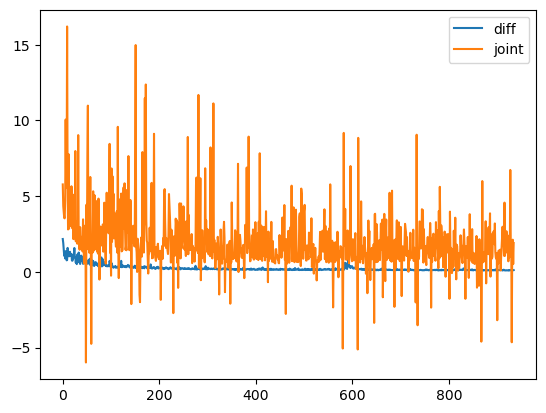

In [13]:
#plt.plot(total_losses['mse'], label='mse')
plt.plot(total_losses['diff'][20:], label='diff')
#plt.plot(total_losses['dist'][20:], label='dist')
plt.plot(total_losses['joint'][20:],label='joint')
plt.legend()
plt.show()


average batch duration 2.3327002422971876
average get-item duration 12.6332419288096


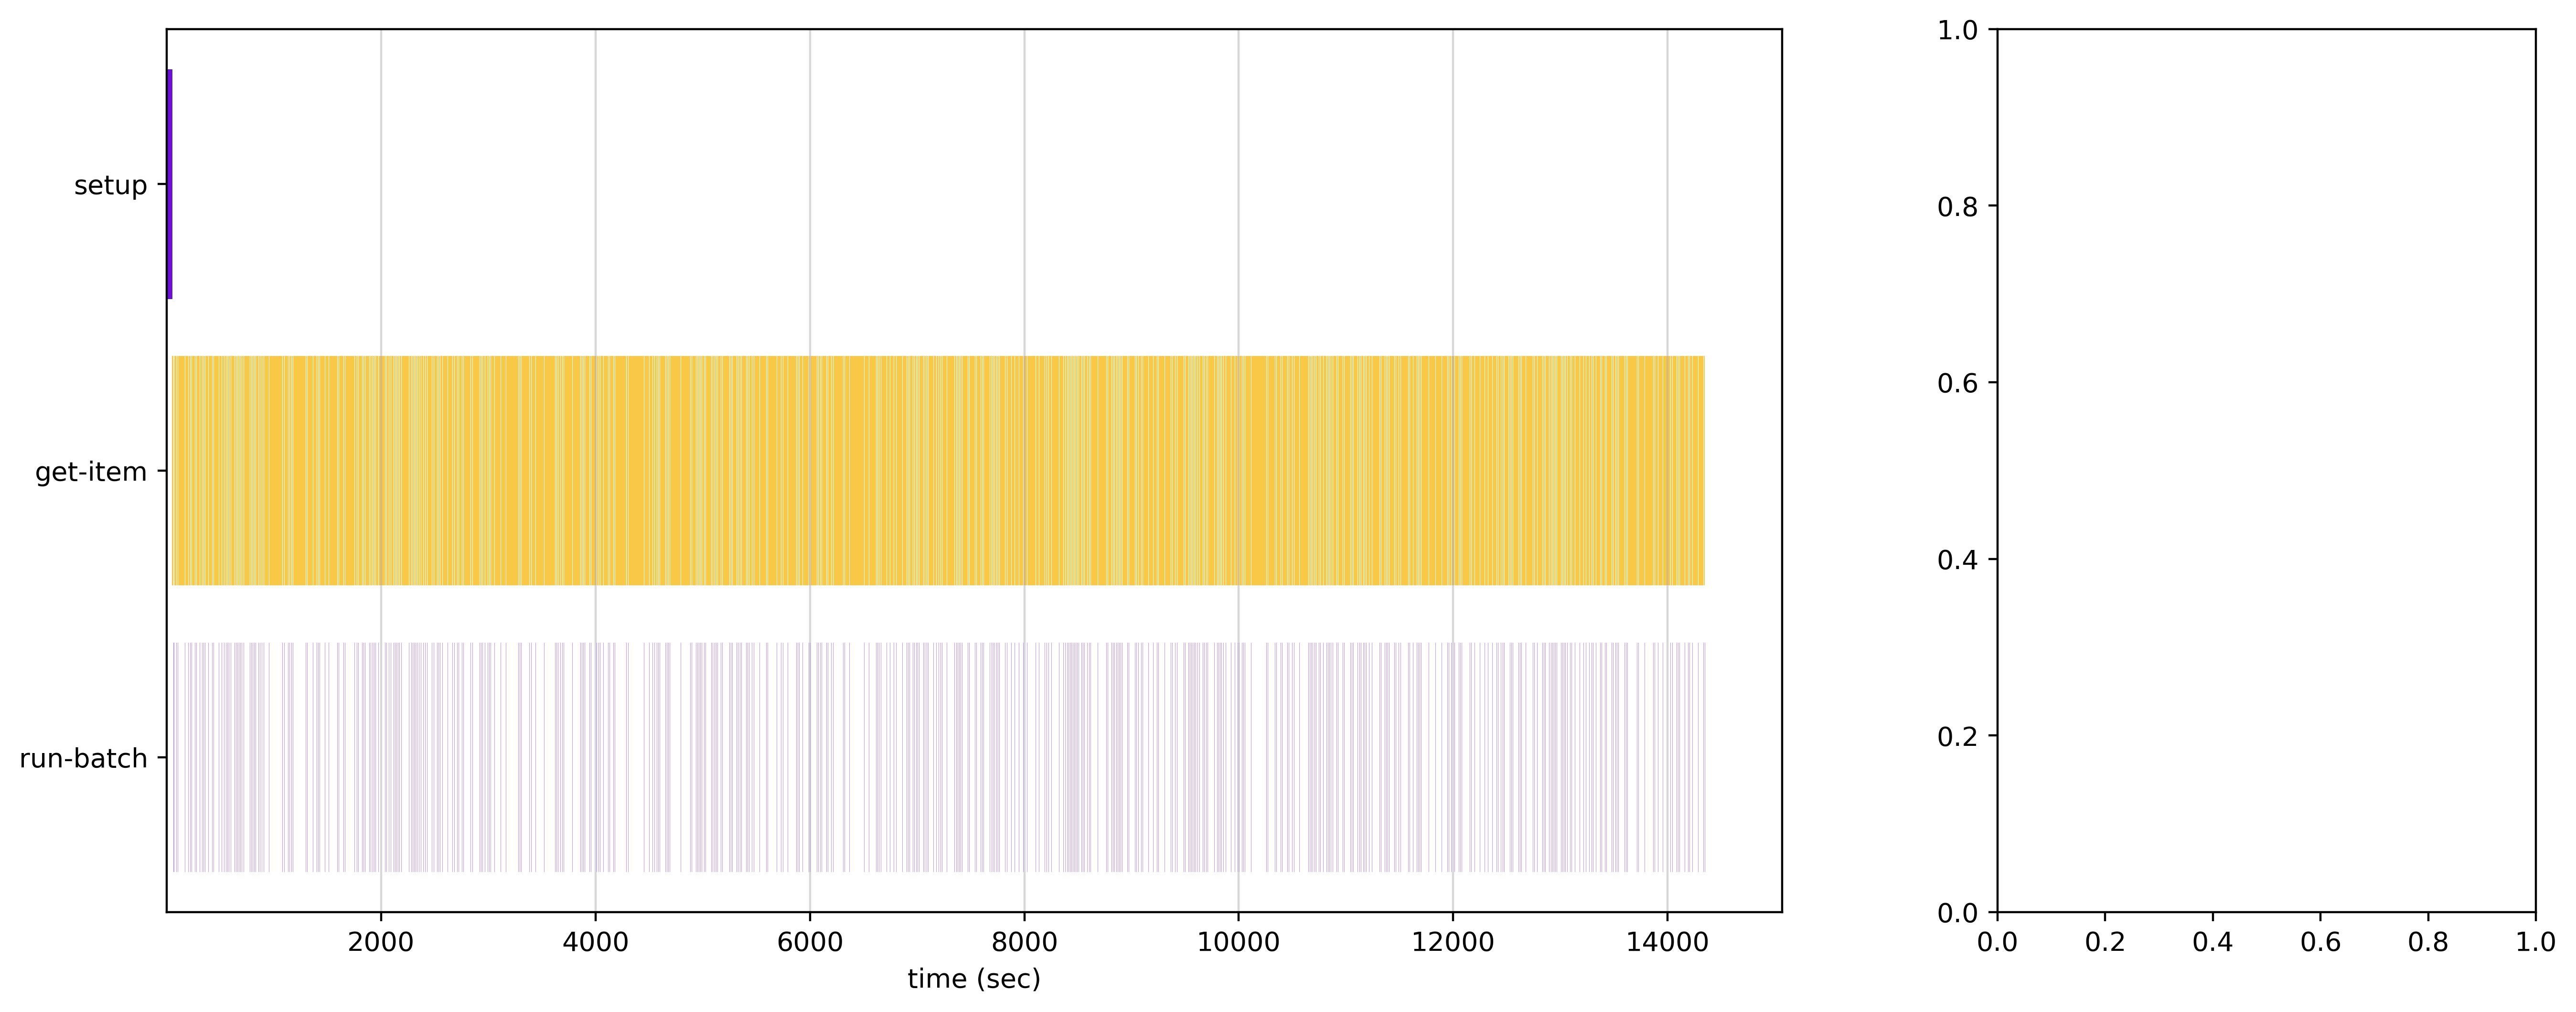

In [14]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16, 6), width_ratios=[3, 1], dpi=400)
plot_log(messages, axes[0], title="")

In [15]:
def eval_density(GMM, x, training=True, return_components=False):
    x = x[:, None]
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] 
    log_probs = -0.5 * torch.log(2 * torch.pi * var) - (x - mu)**2 / (2 * var) 
    probs = torch.exp(log_probs)  # (N, K)
    weighted_probs = pi * probs
    q_x = weighted_probs.sum(dim=1, keepdim=True)  # (N, 1)
    if(return_components):
        return(q_x, weighted_probs)
    return(q_x)


def hist(data, title, **kwargs):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    plt.hist(data, **kwargs)
    if('label' in kwargs):
        plt.legend()
    plt.title(title)

In [113]:

def plot_gmm_distribution(gmm, data, n_points=1000):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    # Create a range of x values to evaluate the GMM on
    x = torch.linspace(data.min(), data.max(), n_points)
    ret = eval_density(gmm, x, training=False, return_components=False)
    # Plot histogram of actual data
    plt.hist(data, bins=50, density=True, alpha=0.5, label='Data')
    
    # Plot GMM density
    plt.plot(x, ret, 'r-', lw=2, label='GMM')
    if(components):
        plt.plot(x, ret[1][:,0], 'b-', lw=2, label='Component 1')
        plt.plot(x, ret[1][:,1], 'g-', lw=2, label='Component 2')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()
    return(ret[0])

# Comparing Across Loss Functions

Four experiments: 
1. Just Mse
2. MSE + Diffusion Prior Loss
3. MSE + Distribution Loss with KSD Gradient, uniform sample of 4 target variables
4. MSE + Distloss + Diffloss

In [19]:
num_models = 4

In [62]:
exp_ids = ["DiffLossTesting"] * num_models
base_run_id = "trial0_test"
run_ids = [f"{base_run_id}{l}" for l in "abcd"]
base_dir = os.path.join(exp_dir, exp_ids[0])
#base_run_id = "trial3"
#run_ids = "trial3-mse trial3-diff trial3-dist trial3-joint".split()
list(zip(exp_ids, run_ids))

[('DiffLossTesting', 'trial0_testa'),
 ('DiffLossTesting', 'trial0_testb'),
 ('DiffLossTesting', 'trial0_testc'),
 ('DiffLossTesting', 'trial0_testd')]

In [85]:
log_dict_path = os.path.join(exp_dir, exp_ids[0], f"{base_run_id}.json")
mconfigs = []
tconfigs = []
with open(log_dict_path, 'r') as f:
    log_dicts = json.load(f)
models = dict()
cid = 'best-'
for i in range(num_models):
    mconfig = tru.ModelConfig(**log_dicts[run_ids[i]]['model_config'])
    tconfig = tru.TrainingConfig(**log_dicts[run_ids[i]]['training_config'])
    mconfigs.append(mconfig)
    tconfigs.append(tconfig)
    ckpt_dir = os.path.join(exp_dir, exp_ids[i], "checkpoints", base_run_id, f"{cid}{run_ids[i]}-ckpt.pt")
    models[run_ids[i]] = tru.load_model_from_ckpt(ckpt_dir, mconfig, baseline=True).to(device)

In [41]:
log_dicts.keys(), log_dicts[run_ids[0]].keys()


(dict_keys(['trial0_testa', 'trial0_testb', 'trial0_testc', 'trial0_testd']),
 dict_keys(['training_config', 'model_config', 'data_config', 'train_epoch_losses', 'losses', 'gradients']))

In [42]:
data_vars = mconfigs[0].data_vars
lws = [tconfigs[i].loss_weights for i in range(num_models)]
data_vars, lws

('v1',
 [{'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0},
  {'mse': 1.0, 'distribution': 0.0, 'diffusion': 10.0},
  {'mse': 1.0, 'distribution': 1.0, 'diffusion': 0.0},
  {'mse': 1.0, 'distribution': 1.0, 'diffusion': 10.0}])

In [43]:
run_id_mapping = dict(zip(run_ids, "trial0-mse trial0-diff trial0-dist trial0-joint".split()))
run_id_mapping

{'trial0_testa': 'trial0-mse',
 'trial0_testb': 'trial0-diff',
 'trial0_testc': 'trial0-dist',
 'trial0_testd': 'trial0-joint'}

## Loss Curves

In [26]:
tconfigs

[TrainingConfig(exp_id='DiffLossTesting', run_id='trial0_testa', num_epochs=5, phases=['train', 'eval'], distributed_training=False, optimizer='adam', betas=[0.9, 0.999], lr_scheduler=None, learning_rate=0.0005, loss_weights={'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}, clip_gradients=True, max_T_sample=100, save_best_epoch=True, batch_logging_interval=16, batch_checkpoint_interval=50, log_gradients=True, push_to_hub=False, diffusion_loss_noise_level=20, diffusion_loss_decoding_interval=1, distloss_type='ksd', num_gaussians=[3, 2, 3, 2], num_distloss_samples=8, distloss_bs=1152, distloss_var_inds=[68, 60, 73, 82], distloss_var_sel='uniform'),
 TrainingConfig(exp_id='DiffLossTesting', run_id='trial0_testb', num_epochs=5, phases=['train', 'eval'], distributed_training=False, optimizer='adam', betas=[0.9, 0.999], lr_scheduler=None, learning_rate=0.0005, loss_weights={'mse': 1.0, 'distribution': 0.0, 'diffusion': 10.0}, clip_gradients=True, max_T_sample=100, save_best_epoch=True, ba

In [29]:
def plot_loss(diff_logs):
    total_timesteps = 210238
    # Get loss types from the first log
    first_log = next(iter(diff_logs.values()))
    loss_types = list(first_log['losses']['train'].keys())
    n_losses = len(loss_types)

    fig, axes = plt.subplots(n_losses, 1, figsize=(8, 4 * n_losses), sharex=True)
    if n_losses == 1:
        axes = [axes]  # Ensure axes is always a list

    for i, loss_type in enumerate(loss_types):
        ax = axes[i]
        for key, log in diff_logs.items():
            dconfig, tconfig = log['data_config'], log['training_config']
            bs = dconfig['dataloader_params']['batch_size'] / 384
            bli = tconfig['batch_logging_interval']
            y = log['losses']['train'][loss_type]
            ax.plot(y, label=f"{run_id_mapping[key]}")
            batches_per_epoch = max(1, total_timesteps * dconfig['train_test_split'][0] // (bs * bli))
            num_batches = len(y)
            num_epochs = tconfig['num_epochs'] + 1
            ax.set_xticks(np.arange(0, num_batches, batches_per_epoch))
            ax.set_xticklabels(np.arange(1, num_epochs))
        ax.set_title(f"{loss_type} Loss over time")
        ax.set_ylabel("Loss")
        ax.legend()
    axes[-1].set_xlabel("Epochs")
    plt.tight_layout()
    plt.show()

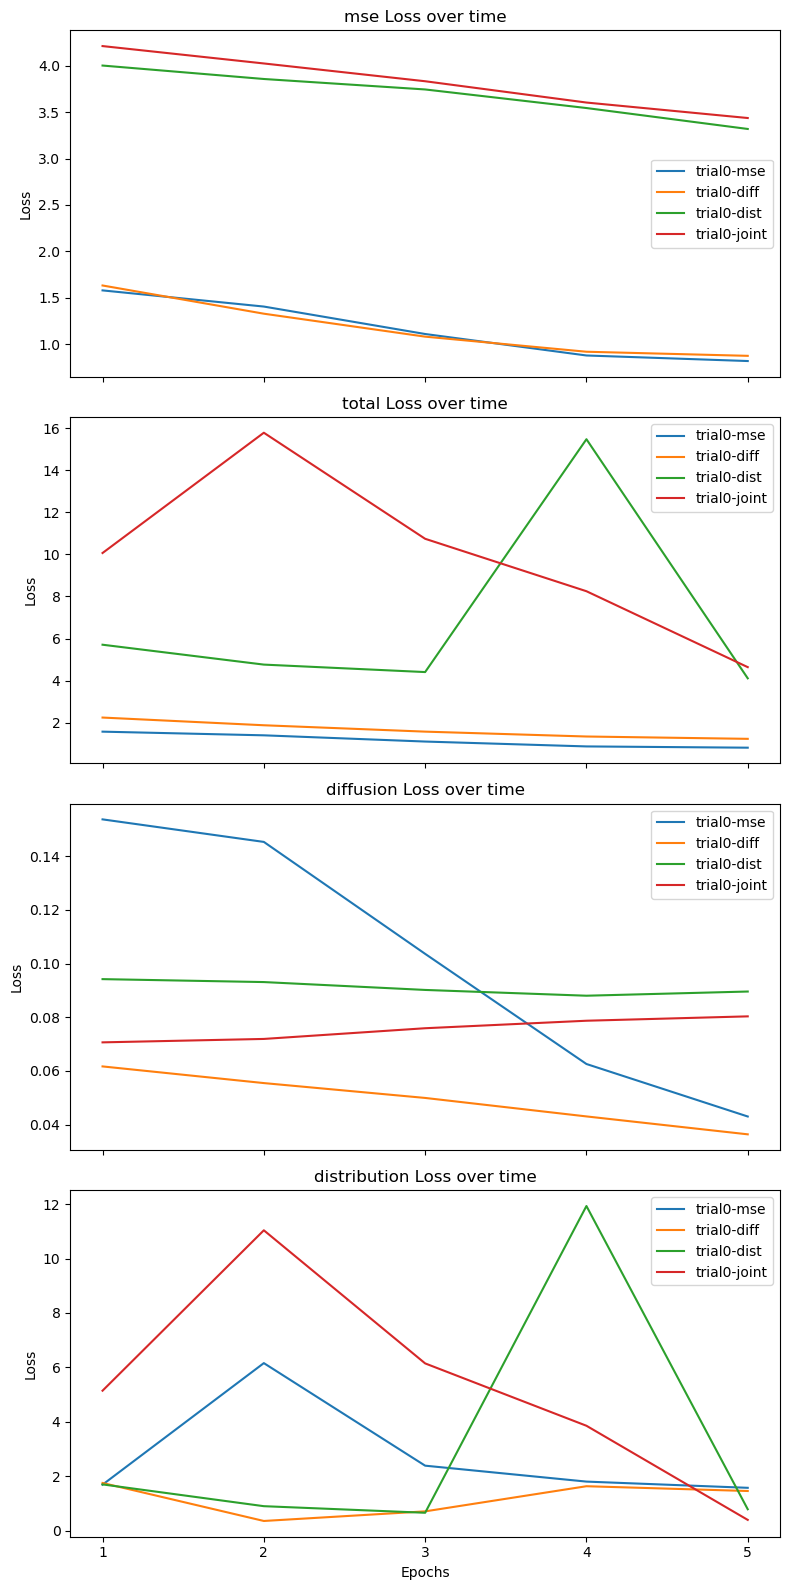

In [30]:
plot_loss(log_dicts)


## Loading data and predictions

In [51]:
dconfig = tru.DataConfig(**log_dicts[run_ids[0]]['data_config'])
pprint(dconfig)

indices = None
if('indices' in log_dicts):
    print("setting indices")
    indices = [np.array(i) for i in log_dicts['indices']]

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.001, 0.001],
           dataloader_params=TrainLoaderParams(batch_size=24576,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=[36, 210240, 144],
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


In [ ]:
trainer = ClimsimTrainer(
    dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), exp_dir, "trial1", 0
)

In [72]:
#dconfig.train_test_split = [0.01, 0.002]
dl, edl = trainer.dataloaders.values()
train_indices, test_indices = trainer.indices
len(edl.dataset)


3

In [66]:
dl.dataset.X.sample.shape[0] / 384 / dconfig.train_test_split[0]

210000.0

In [67]:
bs, bli = dconfig.dataloader_params.batch_size, tconfig.batch_logging_interval
bs, bli

(24576, 16)

In [68]:
if(edl.dataset.X.nbytes / 1e9 < 10):
    from dask.diagnostics import ProgressBar
    with ProgressBar():
        edl.dataset.X.load()
        edl.dataset.Y.load()

    x, y = torch.tensor(edl.dataset.X.data), torch.tensor(edl.dataset.Y.data)

    x.shape, y.shape

[########################################] | 100% Completed | 3.56 sms
[########################################] | 100% Completed | 3.75 sms


### Old test: Just Distloss

In [4]:
#exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_id = "DistLossTesting"
run_id = "trial1"
base_dir = os.path.join(exp_dir, exp_id)
log_dicts = {}
mconfigs = []
distloss_models = {}
base_dir

'/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments/DistLossTesting'

In [ ]:
lettering = 'abcdefghijklmnopqrstuvwxyz'
for i in range(4):
    fpath = os.path.join(base_dir, f"trial1{lettering[i]}.json")
    print(fpath)
    with open(fpath, 'r') as f:
        log_dict = json.load(f)
    model_path = os.path.join(base_dir, "checkpoints", )
    mconfig = tru.ModelConfig(**log_dict['model_config'])
    mconfigs.append(mconfig)
    distloss_models[targeted_vars[i]] = tru.load_model_from_ckpt(f"checkpoints/{run_id}{lettering[i]}-ckpt.pt", mconfig, exp_id, exp_dir, baseline=True)
    log_dicts[targeted_vars[i]] = log_dict


In [ ]:
mse_base_dir = os.path.join(exp_dir, "JointTraining")
with open(mse_base_dir + "/trial0.json", 'r') as f:
    mse_log_dict = json.load(f)
mse_model = tru.load_model_from_ckpt("checkpoints/trial0_just_mse.pt", mse_log_dict['model_config'], "JointTraining", exp_dir, baseline=True).to(device)


/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/training_utils.py:206: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(c

In [10]:
dconfig = tru.my_dconfig(data_vars='v1', in_notebook=True, dataset_type='climsim', batch_size=64)
dconfig.source = "gcsfs"
dconfig.train_test_split = [0.01, 0.002]
dataloaders, indices = tru.load_dataloaders(dconfig, log=True, shuffle_indices=False)

In [11]:
dl, edl = dataloaders
batch = dl.dataset[8]

{"event": "get-batch start", "time": 1746556633.1034007, "pid": 201, "batch_idx": 8}
{"event": "get-batch end", "time": 1746556639.235854, "pid": 201, "batch_idx": 8, "duration": 6.1324462890625}


In [12]:
import dask
from dask.diagnostics import ProgressBar
with ProgressBar():
    edl.dataset.X.load()
    edl.dataset.Y.load()

[########################################] | 100% Completed | 2.53 sms
[########################################] | 100% Completed | 2.76 sms


## Distribution Assessment of Predictions 


Compare the distribution and images predicted by each model to the actual images and actual histograms of select variables

In [78]:
ds = edl.dataset
mli, mlo = ds.mli, ds.mlo
len(ds), ds.X.shape, ds.xgen.input_dims

(3, (80640, 124), {'sample': 24576, 'mli': 124})

In [77]:
print(16146048 // 24576, )
print(24576 / 384)
# generate larger batch than 64
desired_batch_size = 2048 * 384
import xbatcher
ds.xgen = xbatcher.BatchGenerator(ds.X, input_dims=dict(sample=desired_batch_size, mli=ds.dutils.input_feature_len), preload_batch=False,)
ds.ygen = xbatcher.BatchGenerator(ds.Y, input_dims=dict(sample=desired_batch_size, mlo=ds.dutils.target_feature_len), preload_batch=False,)


656
64.0


In [101]:
x, y = ds[2]
x, y = x.to(device), y.to(device)

{"event": "get-item start", "time": 1748586359.0373032, "pid": 1051487, "batch_idx": 2}
{"event": "get-item end", "time": 1748586359.0849729, "pid": 1051487, "batch_idx": 2, "duration": 0.04766440391540527}


In [87]:
m = list(models.values())[0]
for name, p in m.named_parameters():
    print(name, p.shape, p.device)

0.weight torch.Size([256, 124]) cuda:0
0.bias torch.Size([256]) cuda:0
2.weight torch.Size([256, 256]) cuda:0
2.bias torch.Size([256]) cuda:0
4.weight torch.Size([256, 256]) cuda:0
4.bias torch.Size([256]) cuda:0
6.weight torch.Size([128, 256]) cuda:0
6.bias torch.Size([128]) cuda:0


In [102]:
predictions = {}
with torch.no_grad():
    for key in models.keys():
        models[key].eval()
        pred = models[key](x)
        print(pred.isnan().sum().item(), run_id_mapping[key], pred.shape)
        predictions[run_id_mapping[key]] = pred.detach().cpu().numpy()
#predictions['mse'] = mse_model(x)

0 trial0-mse torch.Size([24576, 128])
0 trial0-diff torch.Size([24576, 128])
0 trial0-dist torch.Size([24576, 128])
0 trial0-joint torch.Size([24576, 128])


In [103]:
x, y = x.detach().cpu().numpy(), y.detach().cpu().numpy()

In [106]:
VAR_IND = 68
num_gaussians = 3
y_sel = y[:, VAR_IND]
gmm = GaussianMixture(n_components=num_gaussians)
gmm.fit(y_sel[:, None])

GaussianMixture(n_components=3)

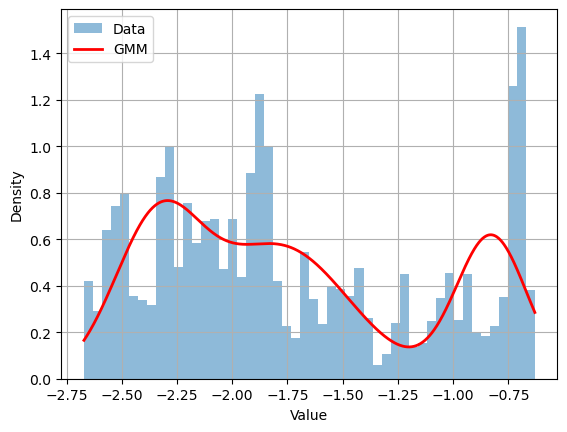

In [115]:
densities = plot_gmm_distribution(gmm, y_sel)

In [130]:


def discrepancy_viewer(predictions, cmap='viridis'):
    # Define interactive plot function
    viewable_keys = list(predictions.keys()) + ['true']
    var_inds = [68, 60, 73, 82]
    num_gaussians = [3, 2, 3, 2]

    def plot_image(var_index, model_index):
        VAR_IND = var_inds[var_index]
        mtype = viewable_keys[model_index]
        y_sel = y[:, VAR_IND]
        gmm = GaussianMixture(n_components=num_gaussians[var_index])
        gmm.fit(y_sel[:, None])
        if(mtype == 'true'):
            pred = y_sel
        else:
            pred = predictions[mtype][:, VAR_IND]

        x = torch.linspace(pred.min(), pred.max(), 1000)
        densities = torch.exp(torch.tensor(gmm.score_samples(x.reshape(-1,1))))
        plt.plot(x, densities, label='gmm density learned from y')
        plt.hist(pred, density=True, label=f'{mtype} predictions', bins=50, alpha=0.75)
        #plt.hist(y_sel, density=True, label='histogram of y', bins=50, alpha=0.5)
        plt.title(f"Predictions of {mlo[VAR_IND].item()} ({VAR_IND}) from model {mtype}")
        plt.legend()

    # Create interactive widgets
    variable_slider = widgets.IntSlider(value=0, min=0, max=len(var_inds)-1, step=1, description='Variable:')
    model_slider = widgets.IntSlider(value=0, min=0, max=len(viewable_keys)-1, step=1, description='Model:')
    interact(plot_image, var_index=variable_slider, model_index=model_slider)
    

In [131]:
discrepancy_viewer(predictions)

interactive(children=(IntSlider(value=0, description='Variable:', max=3), IntSlider(value=0, description='Mode…

In [24]:
lw1 = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
lw2 = {'mse': 1.0, 'distribution': 3e-4, 'diffusion': 0.0}

## Image Comparison

In [141]:
pred_images = {}
for key, pred in predictions.items():
    pred_images[key] = trainer._make_image(torch.tensor(pred)).numpy()
    print(pred_images[key].shape)

keys = list(pred_images.keys())
keys

(64, 128, 16, 24)
(64, 128, 16, 24)
(64, 128, 16, 24)
(64, 128, 16, 24)


['trial0-mse', 'trial0-diff', 'trial0-dist', 'trial0-joint']

In [146]:
len(mlo), mlo[59].item()

(128, ('state_t', 59))

torch.Size([64, 128, 16, 24])

In [158]:
def image_viewer(pred_images=pred_images, cmap='plasma'):
    # Define interactive plot function
    viewable_keys = ['true'] + list(predictions.keys())
    batch_size = pred_images[viewable_keys[-1]].shape[0]
    y_img = trainer._make_image(torch.tensor(y)).numpy()
    def plot_image(batch_index, var_index, model_index):
        var = mlo[var_index].item()
        mtype = viewable_keys[model_index]
        vmap = y_img[batch_index, var_index, :, :] if mtype == 'true' else pred_images[mtype][batch_index, var_index, :, :]
        plt.imshow(vmap, cmap=cmap)
        plt.colorbar()
        plt.title(f"Predictions of {var} from {mtype} model")
        plt.ylabel("Latitude")
        plt.xlabel("Longitude")
        plt.show()

    # Create interactive widgets
    batch_slider = widgets.IntSlider(value=0, min=0, max=batch_size-1, step=1, description='Item:')
    variable_slider = widgets.IntSlider(value=0, min=0, max=len(mlo)-1, step=1, description='Variable:')
    model_slider = widgets.IntSlider(value=0, min=0, max=len(viewable_keys)-1, step=1, description='Model:')
    interact(plot_image, batch_index=batch_slider, var_index=variable_slider, model_index=model_slider)

In [159]:
image_viewer()

interactive(children=(IntSlider(value=0, description='Item:', max=63), IntSlider(value=0, description='Variabl…

# Trying to use data utils
- replicate https://leap-stc.github.io/ClimSim/evaluation/main_figure_generation.html
- https://github.com/leap-stc/ClimSim/blob/main/preprocessing/create_npy_data_splits.ipynb

Inspired by [Climsim guide](https://leap-stc.github.io/ClimSim/evaluation/main_figure_generation.html)

In [160]:
from diffusionsim import climsim_utils as cut
from diffusionsim import mydatasets as data

In [162]:
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.001, 0.001],
           dataloader_params=TrainLoaderParams(batch_size=24576,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=[36, 210240, 144],
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


In [8]:
dutils = cut.setup_data_utils(dconfig.climsim_type, dconfig.source, dconfig.data_vars, 
                            dconfig.use_tendencies, data_dir=dconfig.data_dir)